# Simulation exemplar: every moving part

This notebook **explains and demonstrates** the Agent RPG pipeline end-to-end:

1. **Repository paths** — why `find_repo_root()` matters in Jupyter  
2. **Scenario schema** — `WorldConfig`, `AgentConfig`, `OrchestrationConfig`  
3. **World** — setting, backstory, `background_events`, pacing  
4. **Agents** — identity, Jinja prompts, Hub `model_id`, relationships  
5. **Orchestration** — turn order, memory window, thoughts, stop phrase  
6. **Structured LLM output** — JSON `thought` / `say` / `directed_at`  
7. **Backends** — mock vs Hugging Face Inference vs (optional) local  
8. **`SimulationEngine`** — rounds, speakers, logging  
9. **JSONL events** — `event_type` timeline  
10. **`ReportBuilder`** — summaries and social metrics  
11. **`SIMULATION_CONFIG`** — your knobs for the procedural run  
12. **`build_random_scenario`** — randomized world + cast + dynamics  
13. **Execute, report, plot** — full tailored pipeline  

> Edit **`SIMULATION_CONFIG`** (Step 11), then run Steps 12–13 (and the plot cell).

In [1]:
from pathlib import Path
import sys
for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src = base / "src"
    if (src / "agent_rpg").is_dir():
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        break
from agent_rpg.repo_root import find_repo_root
ROOT = find_repo_root()
print("Repository root:", ROOT)


Repository root: /Users/morningstar/Desktop/Cold_Storage/Agent_RPG_Simulator


## Step 1 — Repository root (`find_repo_root`)
Notebooks often start with the working directory on `notebooks/`, so relative paths like `examples/scenarios/...` would break. `find_repo_root()` walks upward until it sees `pyproject.toml` and `examples/scenarios/`. You can override with env var **`AGENT_RPG_ROOT`**.

In [2]:
from pathlib import Path

examples = ROOT / "examples" / "scenarios"
assert examples.is_dir(), examples
print("Scenario YAML files:")
for p in sorted(examples.glob("*.yaml")):
    print(" -", p.name)

Scenario YAML files:
 - border_conflict.yaml
 - council.yaml
 - minimal.yaml
 - tavern.yaml


## Step 2 — Load a typed scenario (`load_scenario`)
Scenarios are **YAML → Pydantic**: invalid relationships or missing fields fail fast. We load the small **`minimal.yaml`** for a stable reference, then later build a random world.

In [3]:
from agent_rpg.loader import load_scenario, scenario_json_schema

ref = load_scenario(ROOT / "examples" / "scenarios" / "minimal.yaml")
schema = scenario_json_schema()
print("Top-level schema keys:", sorted(schema.get("properties", {}).keys()))
print("Loaded scenario_id:", ref.world.scenario_id, "| agents:", len(ref.agents))

Top-level schema keys: ['agents', 'orchestration', 'world']
Loaded scenario_id: minimal | agents: 2


## Step 3 — World layer (`WorldConfig`)
- **`setting` / `backstory` / `worldbuilding_notes`** — injected into agent system prompts  
- **`background_events`** — optional `round_trigger` (event active from that round onward)  
- **`max_rounds`** — hard cap on simulation length (orchestration can override)

In [4]:
w = ref.world
print("Title:", w.title)
print("max_rounds:", w.max_rounds)
print("background_events:", len(w.background_events))
for ev in w.background_events:
    snip = ev.description if len(ev.description) <= 72 else ev.description[:72] + "..."
    print(f"  - [{ev.id}] trigger={ev.round_trigger!r} :: {snip}")
if not w.background_events:
    print("  (none in minimal.yaml)")

Title: Minimal mock scenario
max_rounds: 2
background_events: 0
  (none in minimal.yaml)


## Step 4 — Agents (`AgentConfig`)
Each agent has **`agent_id`**, **`display_name`**, **`archetype`**, **`occupation`**, **`model_id`** (Hub repo for Inference), **`temperature` / `max_new_tokens`**, **`relationships`** (map of other `agent_id` → prose), and either **`system_prompt`** or **`prompt_template_id`** (Jinja under `src/agent_rpg/templates/agents/`).

In [5]:
for a in ref.agents:
    print(f"{a.agent_id}: {a.display_name} | {a.archetype} | model={a.model_id}")
    print("   relationships:", a.relationships)

alice: Alice | scholar | model=mock/model
   relationships: {'bob': 'study partner'}
bob: Bob | guard | model=mock/model
   relationships: {'alice': 'trusted colleague'}


## Step 5 — Orchestration (`OrchestrationConfig`)
- **`turn_order`**: `round_robin` | `random` | `reactive` (extra router LLM call)  
- **`memory_turns`** — how many prior transcript lines inform context  
- **`enable_thought_phase`** — log `thought` events when the model fills `thought`  
- **`stop_phrase`** — end early if any `say` contains this substring (case-insensitive)

In [6]:
o = ref.orchestration
print("turn_order:", o.turn_order)
print("memory_turns:", o.memory_turns)
print("enable_thought_phase:", o.enable_thought_phase)
print("stop_phrase:", o.stop_phrase)

turn_order: round_robin
memory_turns: 10
enable_thought_phase: True
stop_phrase: None


## Step 6 — Structured model replies (`parse_agent_json_response`)
The engine asks models for **one JSON object** per turn with keys `thought`, `say`, `directed_at` (another agent id or null). Fences ```json ... ``` are tolerated.

In [7]:
from agent_rpg.parse import parse_agent_json_response

sample = '''```json
{"thought":"They are bluffing.", "say":"Show the ledger.", "directed_at": "bob"}
```'''
p = parse_agent_json_response(sample)
print(p.model_dump())

{'thought': 'They are bluffing.', 'say': 'Show the ledger.', 'directed_at': 'bob', 'raw': '```json\n{"thought":"They are bluffing.", "say":"Show the ledger.", "directed_at": "bob"}\n```', 'parse_error': None}


## Step 7 — LLM backends
- **`FakeLLMBackend`** — deterministic tests / no network  
- **`HuggingFaceInferenceBackend`** — `HF_TOKEN`, `InferenceClient.chat_completion`  
- **`TransformersLocalBackend`** — optional extra `[local]`; per-agent `backend: transformers_local`  

The engine picks `local_backend` when an agent declares `transformers_local`.

In [8]:
from agent_rpg.backends.fake import FakeLLMBackend
from agent_rpg.backends.hf_inference import HuggingFaceInferenceBackend

print("FakeLLMBackend:", FakeLLMBackend)
print("HuggingFaceInferenceBackend:", HuggingFaceInferenceBackend)

FakeLLMBackend: <class 'agent_rpg.backends.fake.FakeLLMBackend'>
HuggingFaceInferenceBackend: <class 'agent_rpg.backends.hf_inference.HuggingFaceInferenceBackend'>


## Step 8 — Run a tiny traced simulation (`SimulationEngine`)
One round, mock replies, JSONL under `runs/`.

In [9]:
import json
from agent_rpg import SimulationEngine
from agent_rpg.backends.fake import FakeLLMBackend
from agent_rpg.loader import load_scenario

tiny = load_scenario(ROOT / "examples" / "scenarios" / "minimal.yaml")
tiny.orchestration.max_rounds = 1
tiny.world.max_rounds = 1
tiny.orchestration.enable_thought_phase = False

def one_shot(i, msgs):
    return json.dumps(
        {"thought": "", "say": "(demo line)", "directed_at": None}
    )

trace_dir = SimulationEngine(tiny).run(
    FakeLLMBackend(factory=one_shot),
    output_dir=ROOT / "runs",
    run_id="exemplar_trace",
)
print("JSONL:", trace_dir / "events.jsonl")

JSONL: /Users/morningstar/Desktop/Cold_Storage/Agent_RPG_Simulator/runs/exemplar_trace/events.jsonl


## Step 9 — Inspect JSONL events
Canonical **`event_type`** values include `system`, `world_event`, `thought`, `message`, `error`, `router`, `metric`.

In [10]:
from collections import Counter
from pathlib import Path

lines = (trace_dir / "events.jsonl").read_text(encoding="utf-8").strip().splitlines()
import json as _json

types = Counter(_json.loads(line)["event_type"] for line in lines)
print(dict(types))

{'system': 2, 'message': 2}


## Step 10 — Reports (`ReportBuilder`)
Post-hoc aggregation: timeline, per-agent quotes, **Gini** on turn counts, directed edges, optional **`relationships_config`** when you pass the original `ScenarioConfig`.

In [11]:
from agent_rpg import ReportBuilder

rb = ReportBuilder.from_jsonl(trace_dir / "events.jsonl")
summary = rb.to_dict(scenario=tiny)["summary"]
print(summary)

{'total_events': 4, 'rounds_observed': [0], 'thought_count': 0, 'message_count': 2, 'error_count': 0, 'world_event_count': 0}


## Step 11 — **Your** simulation knobs (`SIMULATION_CONFIG`)
Edit this dict, then run the remaining cells.

| Key | Meaning |
|-----|--------|
| `seed` | `int` for reproducible randomness; `None` = different each run |
| `num_agents` | `2–8` or `None` (random 2–5) |
| `max_rounds` | cap rounds or `None` (random 2–4) |
| `turn_order` | `'round_robin'` / `'random'` / `'reactive'` / `None` (random) |
| `model_id` | Hub model for every agent in this procedural run |
| `enable_thought_phase` | `True` / `False` / `None` (keep generator default) |
| `cap_max_new_tokens` | upper bound per agent after generation |
| `use_hf_if_token` | if `HF_TOKEN` set, use HF backend; else mock |
| `run_id_prefix` | prefix for `runs/<id>/` |
| `mock_stop_probability` | `0..1`: mock `say` may inject `stop_phrase` to end early |

In [12]:
import os

SIMULATION_CONFIG = {
    "seed": 2026,
    "num_agents": 4,
    "max_rounds": 3,
    "turn_order": "round_robin",
    "model_id": "HuggingFaceH4/zephyr-7b-beta",
    "enable_thought_phase": False,
    "cap_max_new_tokens": 200,
    "use_hf_if_token": False,
    "run_id_prefix": "exemplar_rand",
    "mock_stop_probability": 0.2,
}

SIMULATION_CONFIG

{'seed': 2026,
 'num_agents': 4,
 'max_rounds': 3,
 'turn_order': 'round_robin',
 'model_id': 'HuggingFaceH4/zephyr-7b-beta',
 'enable_thought_phase': False,
 'cap_max_new_tokens': 200,
 'use_hf_if_token': False,
 'run_id_prefix': 'exemplar_rand',
 'mock_stop_probability': 0.2}

## Step 12 — Build procedural scenario (`build_random_scenario`)
`build_random_scenario` samples setting, events, roster, relationships, orchestration details, and hyperparameters. Values from **`SIMULATION_CONFIG`** override the RNG where set.

In [13]:
from agent_rpg.random_scenario import build_random_scenario

try:
    from dotenv import load_dotenv

    load_dotenv(ROOT / ".env")
except ImportError:
    pass

rng_seed = SIMULATION_CONFIG.get("seed")
scenario = build_random_scenario(
    seed=rng_seed,
    num_agents=SIMULATION_CONFIG.get("num_agents"),
    max_rounds=SIMULATION_CONFIG.get("max_rounds"),
    model_id=SIMULATION_CONFIG["model_id"],
    turn_order=SIMULATION_CONFIG.get("turn_order"),
)
if SIMULATION_CONFIG.get("enable_thought_phase") is not None:
    scenario.orchestration.enable_thought_phase = SIMULATION_CONFIG["enable_thought_phase"]
cap = SIMULATION_CONFIG.get("cap_max_new_tokens")
if cap is not None:
    for ag in scenario.agents:
        ag.max_new_tokens = min(ag.max_new_tokens, int(cap))

print("scenario_id:", scenario.world.scenario_id)
print("title:", scenario.world.title)
print("agents:", [a.display_name for a in scenario.agents])
print("turn_order:", scenario.orchestration.turn_order)
print("rounds:", scenario.orchestration.max_rounds or scenario.world.max_rounds)

scenario_id: rand_bd25e6c649
title: Storm over the trade docks
agents: ['Elara Frost', 'Pari Ash', 'Hugo Reed', 'Juno Reed']
turn_order: round_robin
rounds: 3


## Step 13 — Execute full run + report + plots
If `use_hf_if_token` and `HF_TOKEN` are set, this calls the Hub; otherwise **`FakeLLMBackend`** returns varied JSON. Reactive turn order consumes an extra mock line for the router.

In [14]:
import json
import os
import random

from agent_rpg import SimulationEngine
from agent_rpg.backends.fake import FakeLLMBackend
from agent_rpg.backends.hf_inference import HuggingFaceInferenceBackend

use_hf = bool(SIMULATION_CONFIG.get("use_hf_if_token") and os.environ.get("HF_TOKEN"))
first_id = scenario.agents[0].agent_id
stop = scenario.orchestration.stop_phrase or ""
p_stop = float(SIMULATION_CONFIG.get("mock_stop_probability") or 0)
run_seed = rng_seed if rng_seed is not None else random.randint(1, 10_000_000)

if use_hf:
    backend = HuggingFaceInferenceBackend()
    print("Using HuggingFaceInferenceBackend")
else:

    def exemplar_factory(i, msgs):
        sysm = (msgs[0].get("content") or "") if msgs else ""
        if "scene director" in sysm.lower():
            return json.dumps({"next_agent_id": first_id})
        opts = [
            {"thought": "weigh odds", "say": "State your terms clearly.", "directed_at": None},
            {"thought": "", "say": "I will not be cornered.", "directed_at": None},
            {"thought": "bluff", "say": "The crowd is watching; choose wisely.", "directed_at": None},
        ]
        r = random.Random(run_seed + i)
        row = dict(opts[r.randint(0, len(opts) - 1)])
        if stop and p_stop > 0 and r.random() < p_stop:
            row = {"thought": "end", "say": stop, "directed_at": None}
        return json.dumps(row)

    backend = FakeLLMBackend(factory=exemplar_factory)
    print("Using FakeLLMBackend")

run_id = f"{SIMULATION_CONFIG['run_id_prefix']}_{run_seed}"
out = SimulationEngine(scenario).run(
    backend,
    output_dir=ROOT / "runs",
    run_id=run_id,
    seed=run_seed if isinstance(run_seed, int) else None,
)
print("Wrote:", out)

Using FakeLLMBackend
Wrote: /Users/morningstar/Desktop/Cold_Storage/Agent_RPG_Simulator/runs/exemplar_rand_2026


In [15]:
rb2 = ReportBuilder.from_jsonl(out / "events.jsonl")
report_md = out / "report.md"
rb2.write_markdown(report_md, scenario=scenario)
full = rb2.to_dict(scenario=scenario)
print("Report:", report_md)
print("Messages:", full["summary"]["message_count"])
print("Gini turns:", round(full["social_dynamics"]["gini_turns"], 4))

Report: /Users/morningstar/Desktop/Cold_Storage/Agent_RPG_Simulator/runs/exemplar_rand_2026/report.md
Messages: 12
Gini turns: 0.0


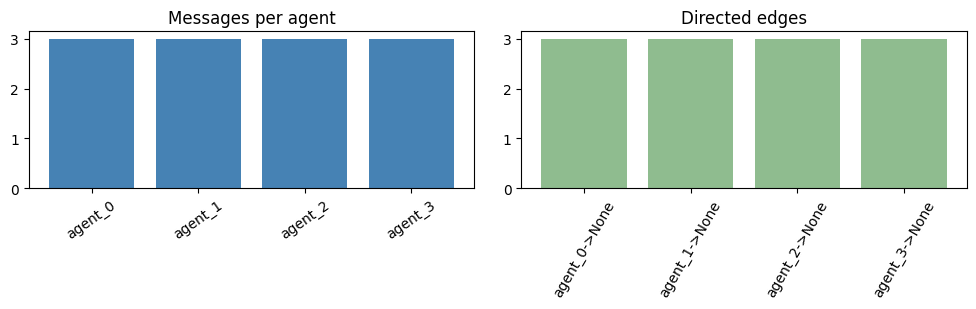

In [16]:
try:
    import matplotlib.pyplot as plt

    soc = full["social_dynamics"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    tc = soc["turn_counts"]
    axes[0].bar(list(tc.keys()), list(tc.values()), color="steelblue")
    axes[0].set_title("Messages per agent")
    axes[0].tick_params(axis="x", rotation=35)
    de = {k: v for k, v in soc.get("directed_edges", {}).items() if v}
    if de:
        axes[1].bar(list(de.keys()), list(de.values()), color="darkseagreen")
        axes[1].set_title("Directed edges")
        axes[1].tick_params(axis="x", rotation=60)
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "No directed_at edges", ha="center")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

### Next steps
- Tweak **`SIMULATION_CONFIG`** and re-run from **Step 12** onward.  
- Point **`model_id`** at any Hub chat model your Inference plan supports.  
- Copy a finished **`events.jsonl`** into analytics tools, or query the optional SQLite mirror from the CLI.  

Regenerate notebook files from the repo: `python scripts/rebuild_notebooks.py`.